In [1]:
from pathlib import Path
import numpy as np
import suite2p
import mbo_utilities as mbo
import lbm_suite2p_python as lsp
import lbm_suite2p_python.zplane

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA RTX A4000,DiscreteGPU,Vulkan,560.94
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
❗ limited,Microsoft Basic Render Driver,CPU,D3D12,
❌,NVIDIA RTX A4000/PCIe/SSE2,Unknown,OpenGL,4.6.0 NVIDIA 560.94


ImportError: cannot import name 'plot_projection' from 'lbm_suite2p_python.utils' (C:\Users\RBO\repos\LBM-Suite2p-Python\lbm_suite2p_python\utils.py)

In [4]:
raw_files = mbo.get_files(r"D:\W2_DATA\wsnyder\2025_03_06\raw\dot_lv6", "tif")
scan = mbo.read_scan(raw_files)

In [18]:
mbo.save_as(scan, "D://demo_anatomical//assembled", target_chunk_mb=100)

Reading tiff series data...
Reading tiff pages...
Raw tiff fully read.


Saving planes:   0%|          | 0/56 [00:00<?, ?it/s]

Time elapsed: 0 minutes 17 seconds.


In [2]:
assembled_files = mbo.get_files("D://demo_anatomical//assembled", 'tif')
assembled_files

['D:\\demo_anatomical\\assembled\\plane_01.tif',
 'D:\\demo_anatomical\\assembled\\plane_02.tif',
 'D:\\demo_anatomical\\assembled\\plane_03.tif',
 'D:\\demo_anatomical\\assembled\\plane_04.tif',
 'D:\\demo_anatomical\\assembled\\plane_05.tif',
 'D:\\demo_anatomical\\assembled\\plane_06.tif',
 'D:\\demo_anatomical\\assembled\\plane_07.tif',
 'D:\\demo_anatomical\\assembled\\plane_08.tif',
 'D:\\demo_anatomical\\assembled\\plane_09.tif',
 'D:\\demo_anatomical\\assembled\\plane_10.tif',
 'D:\\demo_anatomical\\assembled\\plane_11.tif',
 'D:\\demo_anatomical\\assembled\\plane_12.tif',
 'D:\\demo_anatomical\\assembled\\plane_13.tif',
 'D:\\demo_anatomical\\assembled\\plane_14.tif']

In [ ]:
iw = mbo.run_gui(assembled_files[7])
iw.show()

In [22]:
iw.close()

In [13]:
demo_file = assembled_files[6]
metadata = mbo.get_metadata(demo_file)
base_ops = mbo.params_from_metadata(metadata, base_ops=suite2p.default_ops())
demo_file,  base_ops["anatomical_only"], base_ops["tau"], base_ops["threshold_scaling"]

Setting pipeline to suite2p


('D:\\demo_anatomical\\assembled\\plane_07.tif', 0, 1.0, 1.0)

In [14]:
from copy import deepcopy
ops = base_ops
ops["tau"] = 0.15
ops["max_overlap"] = 1.0
ops["anatomical_only"] = 4
ops["cellprob_thresh"] = -6
ops["diameter"] = 7
ops["spatial_hp_cp"] = 1.5

{'data_path': ['D:\\demo_anatomical\\assembled'], 'save_folder': 'plane_07', 'save_path0': 'D:\\demo_anatomical\\results', 'tiff_list': ['plane_07.tif']}
tif
** Found 1 tifs - converting to binary **
time 0.75 sec. Wrote 903 frames per binary for 1 planes
>>>>>>>>>>>>>>>>>>>>> PLANE 0 <<<<<<<<<<<<<<<<<<<<<<
NOTE: not registered / registration forced with ops['do_registration']>1
      (no previous offsets to delete)
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 6.59 sec.
Registered 500/903 in 7.24s
Registered 903/903 in 13.10s
----------- Total 21.28 sec
----------- ROI DETECTION
Binning movie in chunks of length 03
Binned movie of size [301,442,438] created in 0.37 sec.
>>>> CELLPOSE finding masks in max_proj
!NOTE! diameter set to 7.00 for cell detection with cellpose
>>>> 148 masks detected, median diameter = 6.77 
Detected 148 ROIs, 5.48 sec
After removing overlaps, 148 ROIs remain
----------- Total 6.10 sec.


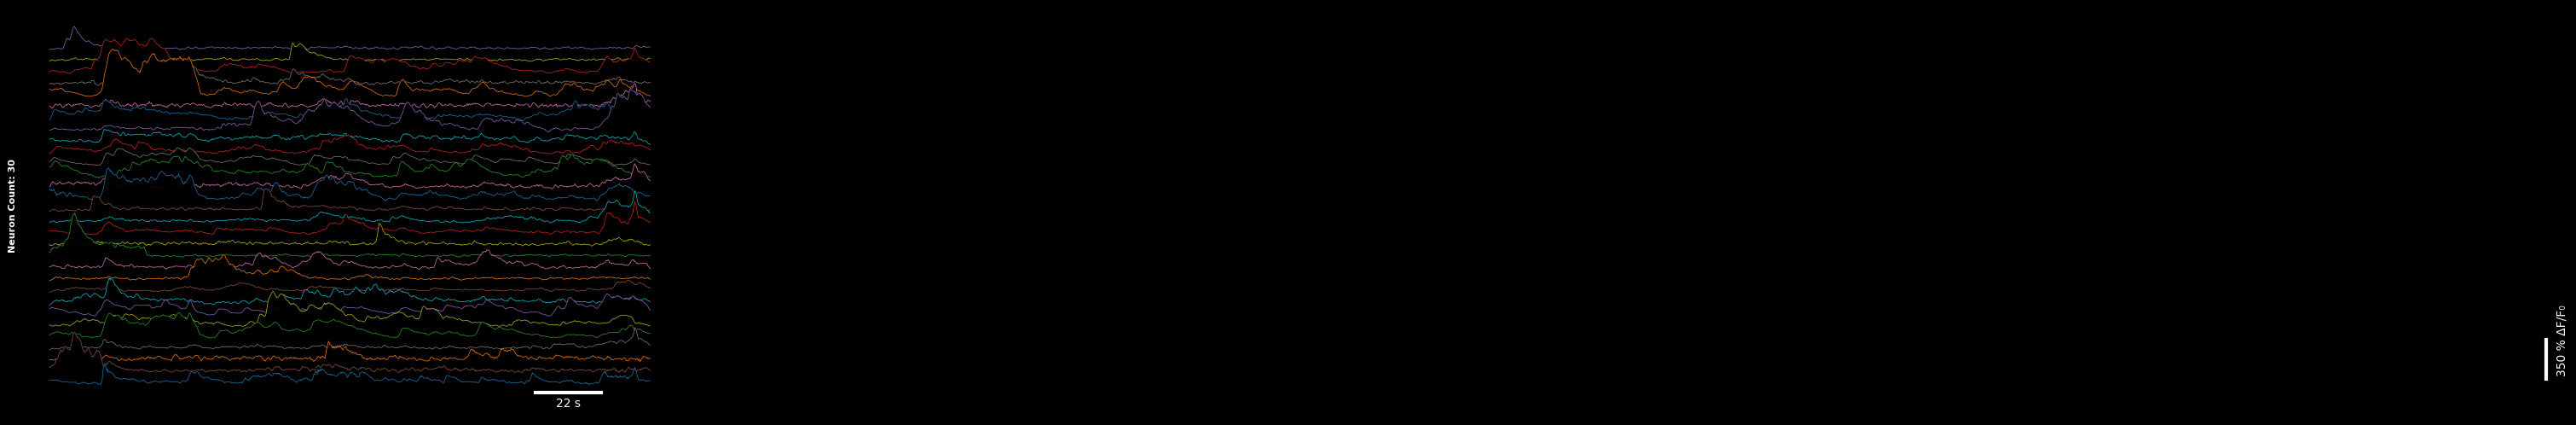

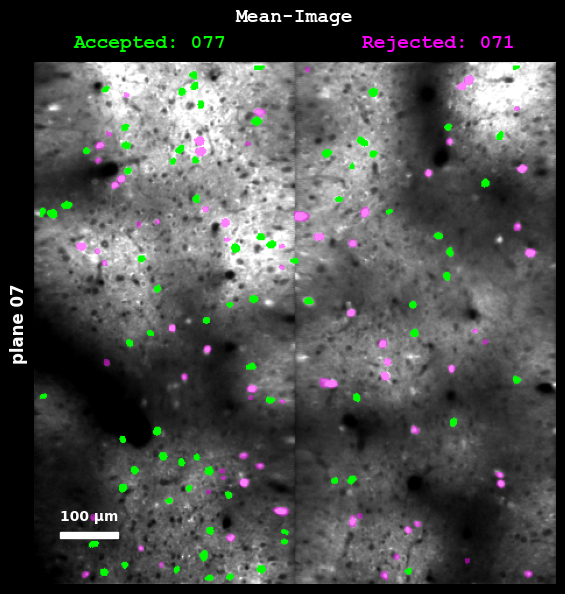

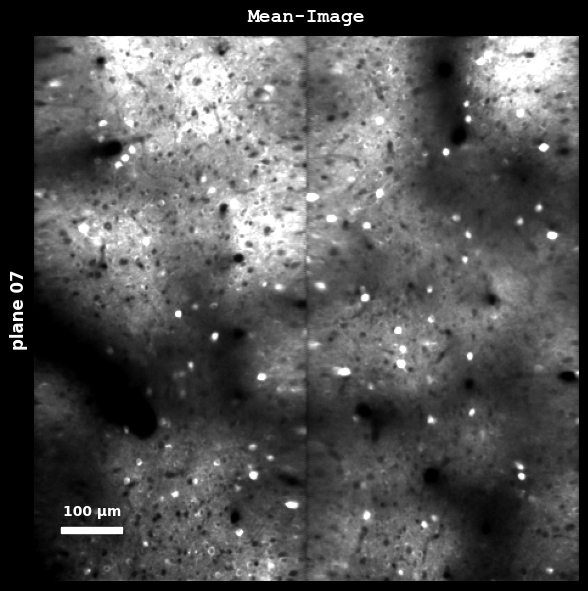

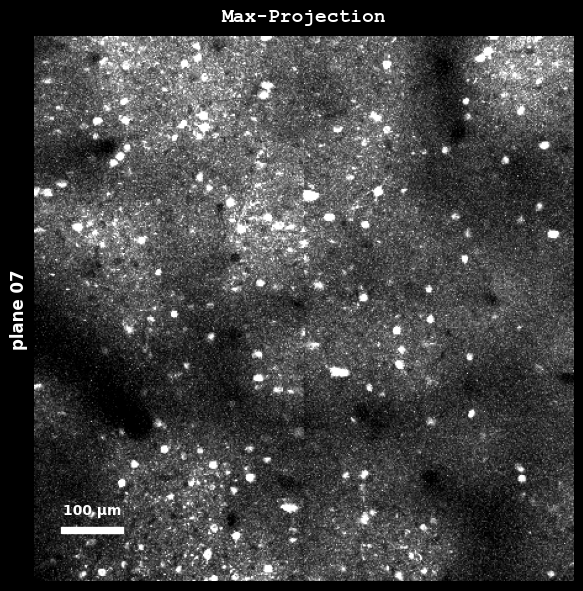

In [12]:
output_ops = lsp.run_plane(ops, demo_file, "D://demo_anatomical//results", save_folder=None, overwrite=True)

In [17]:
# minimal
ops = deepcopy(base_ops)
ops["tau"] = 0.15
ops["max_overlap"] = 1.0
ops["anatomical_only"] = 0

{'data_path': ['D:\\demo_anatomical\\assembled'], 'save_folder': 'plane_07', 'save_path0': 'D:\\demo_functional\\results', 'tiff_list': ['plane_07.tif']}
tif
** Found 1 tifs - converting to binary **
time 0.78 sec. Wrote 903 frames per binary for 1 planes
>>>>>>>>>>>>>>>>>>>>> PLANE 0 <<<<<<<<<<<<<<<<<<<<<<
NOTE: not registered / registration forced with ops['do_registration']>1
      (no previous offsets to delete)
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 6.57 sec.
Registered 500/903 in 7.40s
Registered 903/903 in 13.30s
----------- Total 21.45 sec
----------- ROI DETECTION
Binning movie in chunks of length 03
Binned movie of size [301,442,438] created in 0.35 sec.
NOTE: estimated spatial scale ~6 pixels, time epochs 1.00, threshold 5.00 
0 ROIs, score=139.10
1000 ROIs, score=5.24
Detected 1313 ROIs, 4.86 sec
After removing overlaps, 1313 ROIs remain
----------- Total 6.25 sec.
----------- EXTRACTION
Masks c

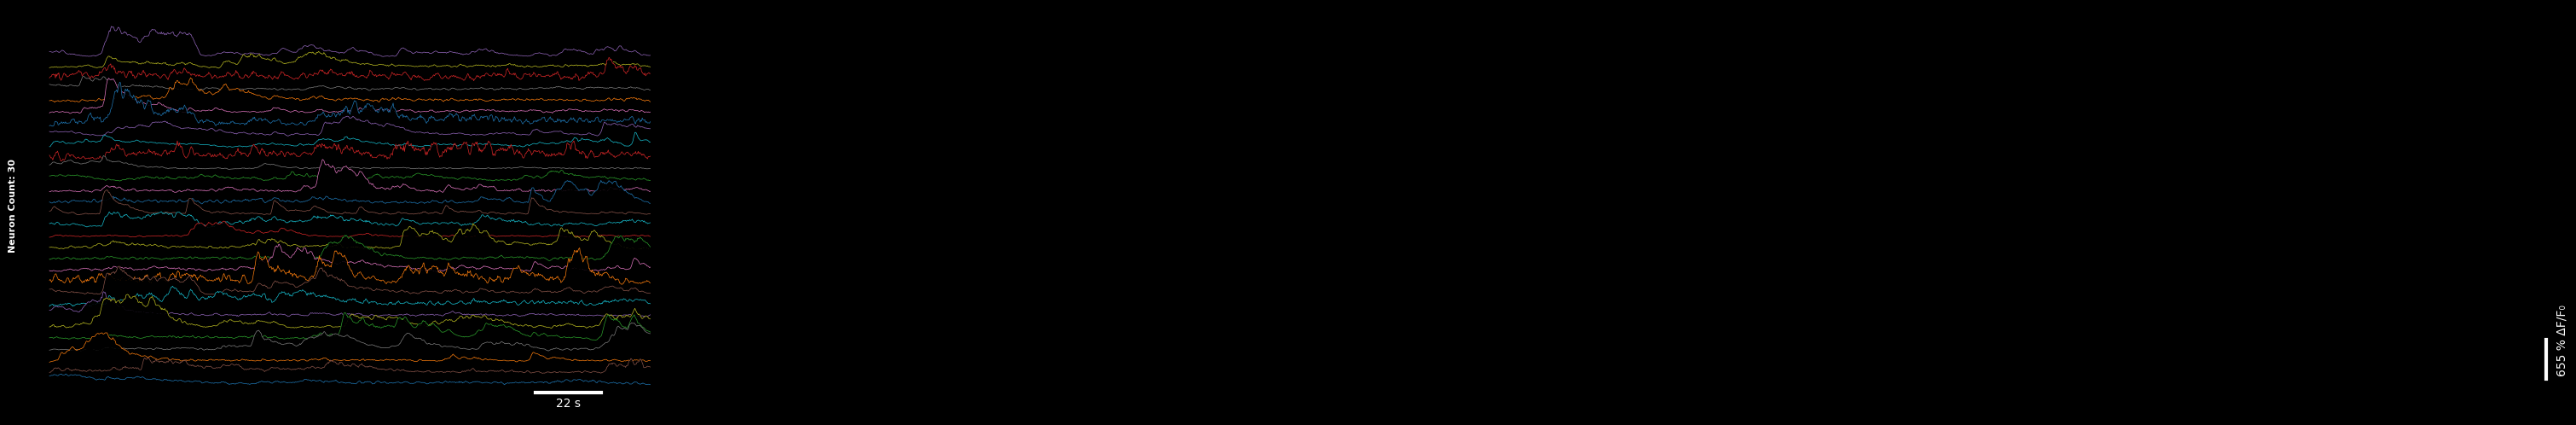

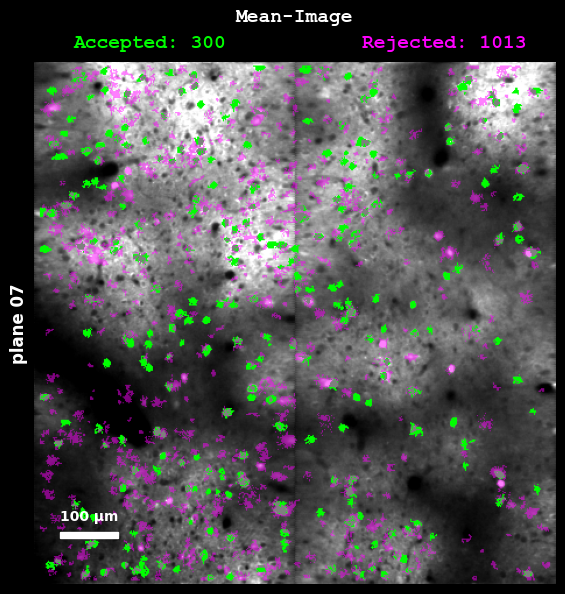

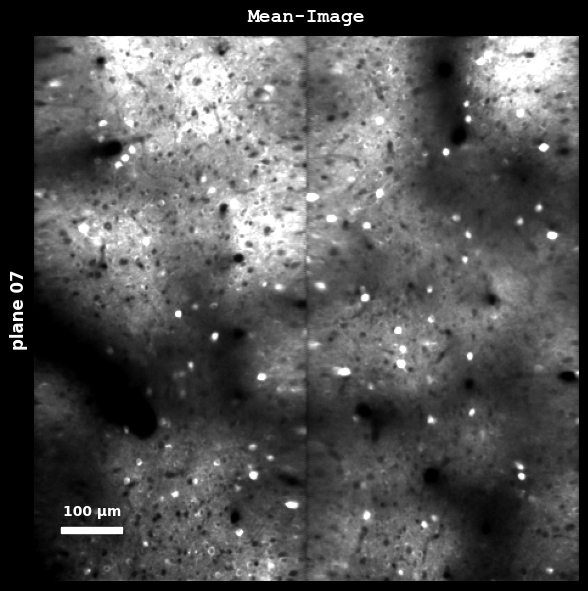

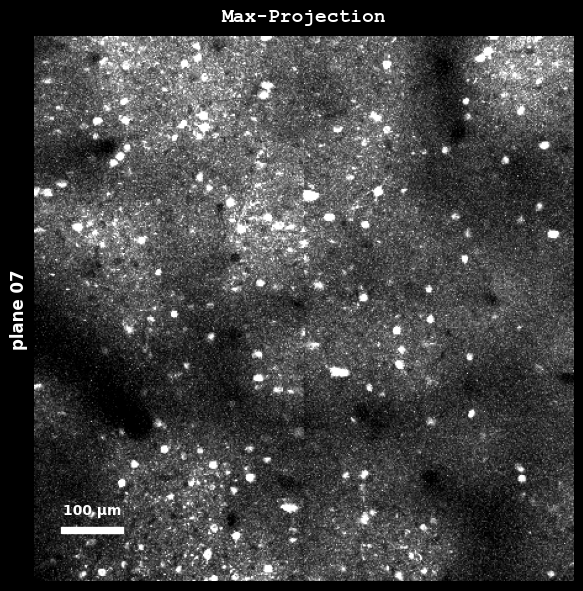

In [18]:
output_ops = lsp.run_plane(ops, demo_file, "D://demo_functional//results", save_folder=None, overwrite=True)

In [ ]:
import os
os.mkdir("D://demo_anatomical//results//figures")

In [19]:
f, fneu, spks = lsp.load_traces(output_ops)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\demo_functional\\results\\plane_07\\plane0\\stats.npy'

In [54]:
stats[0]["skew"]

0.18128827

D:\demo_anatomical\assembled\plane_07.tif already has segmentation results. Skipping execution.
Generating missing plots for plane_07...
{'registration': 21.936908721923828, 'detection': 5.8625617027282715, 'extraction': 0.6053845882415771, 'classification': 0.019999265670776367, 'deconvolution': 0.015508651733398438, 'total_plane_runtime': 28.45737934112549}


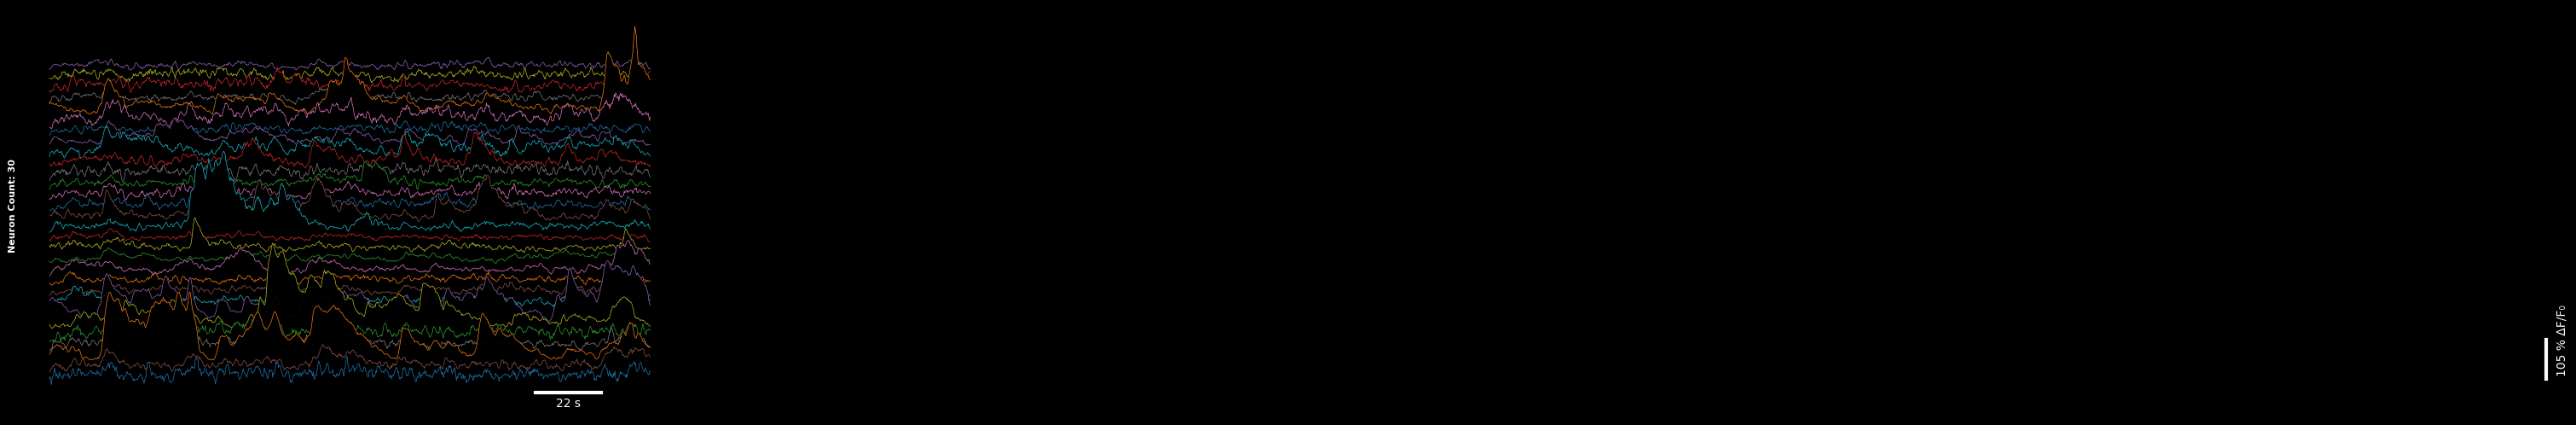

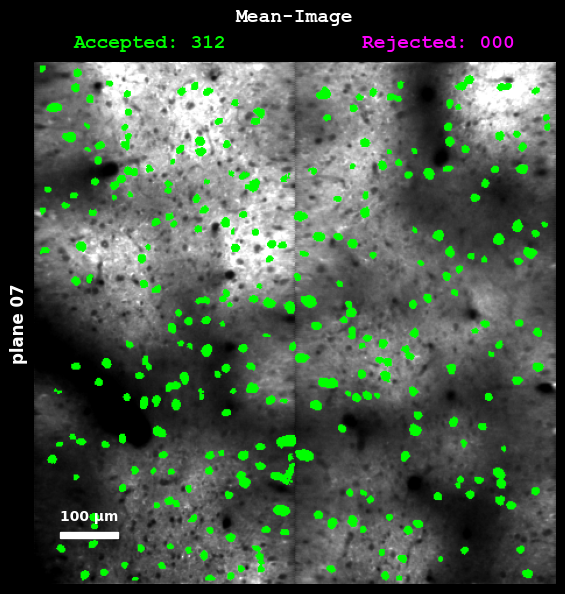

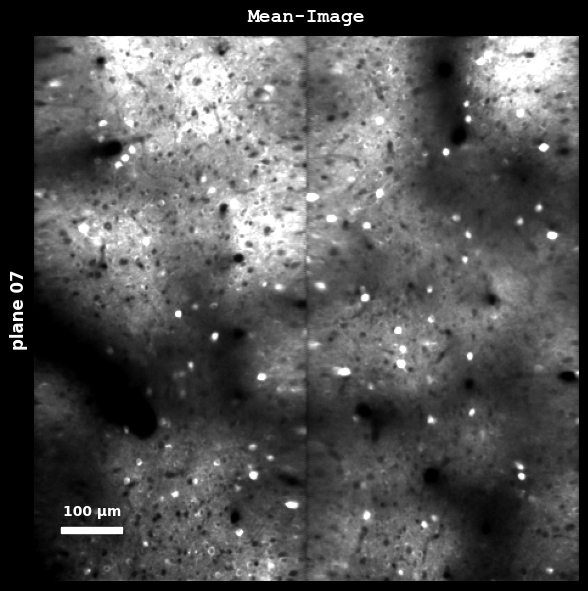

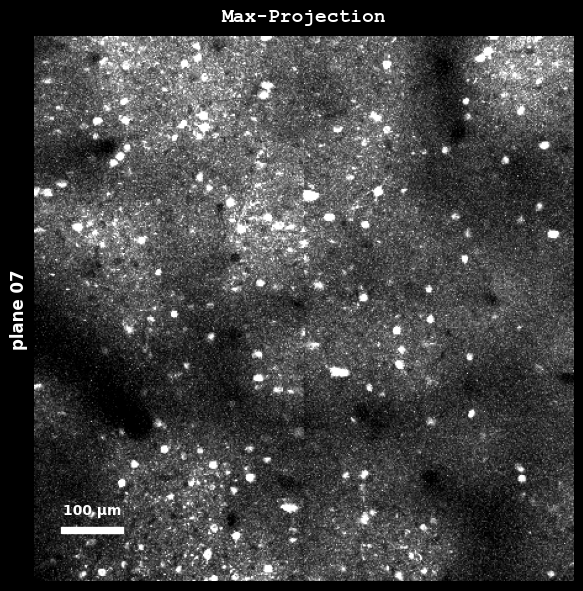

In [59]:
ops["tau"] = 0.15
ops["max_overlap"] = 1.0
ops["anatomical_only"] = 3
ops["cellprob_thresh"] = -6
ops["diameter"] = 7
ops["spatial_hp_cp"] = 1

output_ops = lsp.run_plane(ops, demo_file, "D://demo_anatomical//results", save_folder=None, overwrite=True)

In [ ]:
gs = {spatial_hp_cp}
lsp.run_grid_search(ops, {}